# Step 1: Granger Causality Analysis
## Pairwise GC with FDR Threshold

**Input:** Preprocessed EEG `.npy` (62 channels, 100Hz)
**Output:** GC matrices per trial (raw F-statistic + p-values + thresholded)

**Alur:**
1. Load preprocessed EEG per trial
2. Z-score normalization + stationarity check
3. Compute pairwise Granger Causality (F-statistic + p-values)
4. Apply threshold: FDR / Bonferroni / Percentile
5. Save results per trial
6. Analisis density


In [1]:
import numpy as np
import os
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, sosfiltfilt, iirnotch, filtfilt, resample_poly
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported")


✓ Libraries imported


## 1. Konfigurasi

In [2]:
INPUT_DIR = r"D:\Skripsi\new_data\00_preprocessing\output\preprocessed_eeg"
OUTPUT_DIR = r"D:\Skripsi\new_data\01_granger_causality\output\gc_matrices"
FIGURES_DIR = r"D:\Skripsi\new_data\01_granger_causality\output\figures"

GC_MAX_LAG = 10
GC_ALPHA = 0.05
THRESHOLD_METHOD = "fdr"      # "fdr", "bonferroni", "percentile"
GC_PERCENTILE = 90            # top 10% (only for percentile method)

N_CHANNELS = 62
TARGET_FS = 100
TRIAL_LABELS = [1, 0, -1, -1, 0, 1, -1, 0, 1, 1, 0, -1, 0, 1, -1]
EMOTION_MAP = {-1: "negative", 0: "neutral", 1: "positive"}

CHANNEL_NAMES = [
    "Fp1", "Fpz", "Fp2", "AF3", "AF4", "F7", "F5", "F3", "F1", "Fz",
    "F2", "F4", "F6", "F8", "FT7", "FC5", "FC3", "FC1", "FCz", "FC2",
    "FC4", "FC6", "FT8", "T7", "C5", "C3", "C1", "Cz", "C2", "C4",
    "C6", "T8", "TP7", "CP5", "CP3", "CP1", "CPz", "CP2", "CP4", "CP6",
    "TP8", "P7", "P5", "P3", "P1", "Pz", "P2", "P4", "P6", "P8",
    "PO7", "PO5", "PO3", "POz", "PO4", "PO6", "PO8", "CB1", "O1", "Oz",
    "O2", "CB2",
]

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"✓ Config loaded")
print(f"  Input:  {INPUT_DIR}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Max lag: {GC_MAX_LAG}, Threshold: {THRESHOLD_METHOD}")


✓ Config loaded
  Input:  D:\Skripsi\new_data\00_preprocessing\output\preprocessed_eeg
  Output: D:\Skripsi\new_data\01_granger_causality\output\gc_matrices
  Max lag: 10, Threshold: fdr


## 2. Fungsi Granger Causality

In [3]:
def check_stationarity(ts):
    """ADF test for stationarity"""
    try:
        result = adfuller(ts, autolag='AIC')
        return result[1] < 0.05
    except:
        return False

def make_stationary(data):
    """Differencing for non-stationary channels"""
    n_tp, n_ch = data.shape
    result = np.zeros_like(data)
    for ch in range(n_ch):
        ts = data[:, ch]
        if not check_stationarity(ts):
            ts = np.diff(ts)
            result[:len(ts), ch] = ts
            result[len(ts):, ch] = ts[-1]
        else:
            result[:, ch] = ts
    return result

def normalize_channels(data):
    """Z-score per channel"""
    mean = data.mean(axis=0, keepdims=True)
    std = data.std(axis=0, keepdims=True)
    std[std < 1e-10] = 1.0
    return (data - mean) / std

def preprocess_for_gc(eeg_data):
    """Prepare EEG for GC: (channels, time) → (time, channels)"""
    data = eeg_data.T
    data = normalize_channels(data)
    data = make_stationary(data)
    return data

print("✓ Preprocessing functions defined")


✓ Preprocessing functions defined


In [4]:
def compute_gc_pairwise(data, max_lag=10):
    """
    Pairwise Granger Causality.
    
    Args:
        data: (n_timepoints, n_channels) — stationary & normalized
    
    Returns:
        gc_matrix: (n_ch, n_ch) F-statistic values
        p_matrix:  (n_ch, n_ch) p-values (min across lags)
    """
    n_ch = data.shape[1]
    gc_matrix = np.zeros((n_ch, n_ch))
    p_matrix = np.ones((n_ch, n_ch))
    
    for i in range(n_ch):
        for j in range(n_ch):
            if i == j:
                continue
            try:
                test_data = data[:, [j, i]]  # j → i
                if np.any(np.isnan(test_data)) or np.any(np.isinf(test_data)):
                    continue
                
                result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
                
                best_p = 1.0
                best_f = 0.0
                for lag in range(1, max_lag + 1):
                    f_stat = result[lag][0]['ssr_ftest'][0]
                    p_val = result[lag][0]['ssr_ftest'][1]
                    if p_val < best_p:
                        best_p = p_val
                        best_f = f_stat
                
                gc_matrix[i, j] = best_f
                p_matrix[i, j] = best_p
            except:
                continue
    
    return gc_matrix, p_matrix

print("✓ GC computation function defined")


✓ GC computation function defined


In [5]:
def apply_threshold(gc_matrix, p_matrix, method="fdr", alpha=0.05, percentile=90):
    """
    Apply statistical threshold to GC matrix.
    
    Methods:
      - "fdr":         Benjamini-Hochberg FDR correction
      - "bonferroni":  Bonferroni correction (very strict)
      - "percentile":  Keep top X% + p < alpha
    """
    n_ch = gc_matrix.shape[0]
    thresholded = gc_matrix.copy()
    np.fill_diagonal(thresholded, 0)
    
    if method == "bonferroni":
        n_tests = n_ch * (n_ch - 1)
        alpha_corrected = alpha / n_tests
        mask = p_matrix >= alpha_corrected
        np.fill_diagonal(mask, True)
        thresholded[mask] = 0
        
    elif method == "fdr":
        mask_offdiag = ~np.eye(n_ch, dtype=bool)
        p_flat = p_matrix[mask_offdiag]
        reject, _, _, _ = multipletests(p_flat, alpha=alpha, method='fdr_bh')
        reject_matrix = np.ones((n_ch, n_ch), dtype=bool)
        reject_matrix[mask_offdiag] = reject
        np.fill_diagonal(reject_matrix, False)
        thresholded[~reject_matrix] = 0
        
    elif method == "percentile":
        nonzero = gc_matrix[gc_matrix > 0]
        if len(nonzero) > 0:
            threshold = np.percentile(nonzero, percentile)
            thresholded[thresholded < threshold] = 0
        mask = p_matrix >= alpha
        np.fill_diagonal(mask, True)
        thresholded[mask] = 0
    
    return thresholded

def compute_network_density(matrix):
    n_ch = matrix.shape[0]
    n_possible = n_ch * (n_ch - 1)
    n_edges = np.count_nonzero(matrix)
    return n_edges / n_possible if n_possible > 0 else 0

print("✓ Threshold functions defined")


✓ Threshold functions defined


## 3. Test pada 1 Trial
### (Auto-skip jika hasil sudah ada di output)

In [6]:
# === Check apakah trial 01 sudah pernah dihitung ===
sample_out_dir = os.path.join(OUTPUT_DIR, "subject_01", "session_20131027")
gc_raw_path = os.path.join(sample_out_dir, "gc_raw_trial_01.npy")
p_mat_path = os.path.join(sample_out_dir, "p_values_trial_01.npy")

if os.path.exists(gc_raw_path) and os.path.exists(p_mat_path):
    print("✓ Trial 01 sudah pernah dihitung — loading dari file (skip recomputation)")
    gc_raw = np.load(gc_raw_path)
    p_matrix = np.load(p_mat_path)
    print(f"  Loaded: {gc_raw_path}")
    print(f"  Shape: {gc_raw.shape}")
else:
    # Load one preprocessed trial
    sample_path = os.path.join(INPUT_DIR, "subject_01", "session_20131027", "trial_01.npy")
    eeg = np.load(sample_path)
    print(f"Loaded: {sample_path}")
    print(f"  Shape: {eeg.shape} @ {TARGET_FS}Hz")
    print(f"  Label: {TRIAL_LABELS[0]} ({EMOTION_MAP[TRIAL_LABELS[0]]})")

    # Preprocess for GC
    data = preprocess_for_gc(eeg)
    print(f"\nPreprocessed for GC: {data.shape}")

    # Compute GC
    print(f"\nComputing GC (max_lag={GC_MAX_LAG})...")
    t0 = time.time()
    gc_raw, p_matrix = compute_gc_pairwise(data, max_lag=GC_MAX_LAG)
    t1 = time.time()
    print(f"✓ Done in {t1-t0:.1f}s")

    # Save supaya tidak perlu hitung ulang
    os.makedirs(sample_out_dir, exist_ok=True)
    np.save(gc_raw_path, gc_raw)
    np.save(p_mat_path, p_matrix)
    print(f"  Saved to: {sample_out_dir}")

# Raw stats
n_possible = N_CHANNELS * (N_CHANNELS - 1)
print(f"\n--- Raw GC ---")
print(f"  Non-zero: {np.count_nonzero(gc_raw)}/{n_possible}")
print(f"  Density: {compute_network_density(gc_raw):.3f}")
print(f"  F-stat: min={gc_raw[gc_raw>0].min():.2f}, max={gc_raw.max():.2f}, mean={gc_raw[gc_raw>0].mean():.2f}")
print(f"  P-values: min={p_matrix[p_matrix<1].min():.6f}, median={np.median(p_matrix[p_matrix<1]):.4f}")


✓ Trial 01 sudah pernah dihitung — loading dari file (skip recomputation)
  Loaded: D:\Skripsi\new_data\01_granger_causality\output\gc_matrices\subject_01\session_20131027\gc_raw_trial_01.npy
  Shape: (62, 62)

--- Raw GC ---
  Non-zero: 3782/3782
  Density: 1.000
  F-stat: min=0.07, max=10572.70, mean=145.04
  P-values: min=0.000000, median=0.0000


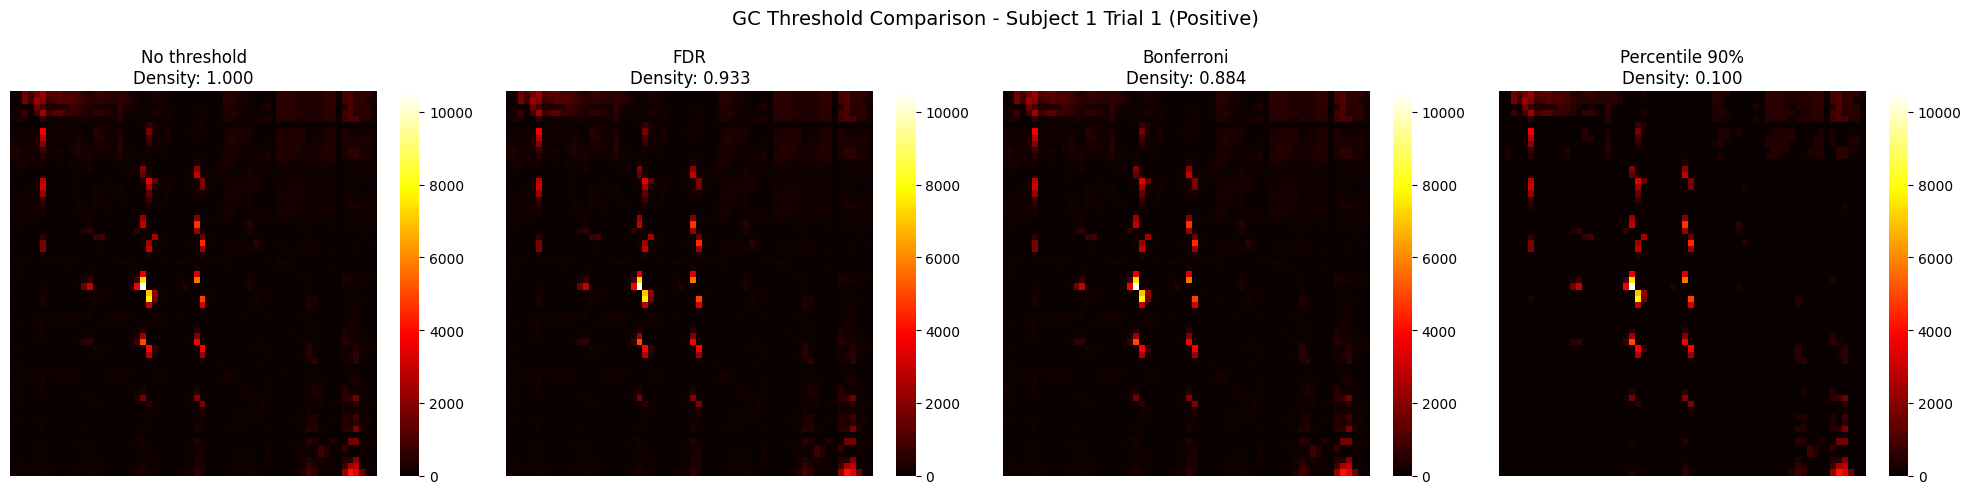

In [7]:
# Compare threshold methods
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

methods = [("No threshold", None), ("FDR", "fdr"), ("Bonferroni", "bonferroni"), ("Percentile 90%", "percentile")]

for ax, (title, method) in zip(axes, methods):
    if method is None:
        matrix = gc_raw.copy()
        np.fill_diagonal(matrix, 0)
    else:
        matrix = apply_threshold(gc_raw, p_matrix, method=method)
    
    density = compute_network_density(matrix)
    hm = sns.heatmap(matrix, cmap='hot', ax=ax, xticklabels=False, yticklabels=False,
                      cbar_kws={'shrink': 0.85})
    hm.collections[0].colorbar.ax.tick_params(labelsize=22)
    ax.set_title(f"{title}\nDensity: {density:.3f}", fontsize=26)

plt.suptitle("GC Threshold Comparison - Subject 1 Trial 1 (Positive)", fontsize=34)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gc_threshold_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()


## 4. Run GC untuk Semua Trial
### (Auto-skip trial yang sudah selesai)

In [ ]:
# === Scan progress: hitung trial yang sudah selesai vs total ===
total_input_trials = 0
completed_trials = 0
trial_list = []

for subj_dir in sorted(os.listdir(INPUT_DIR)):
    subj_path = os.path.join(INPUT_DIR, subj_dir)
    if not os.path.isdir(subj_path):
        continue
    for sess_dir in sorted(os.listdir(subj_path)):
        sess_path = os.path.join(subj_path, sess_dir)
        if not os.path.isdir(sess_path):
            continue
        for trial_file in sorted(os.listdir(sess_path)):
            if not trial_file.endswith('.npy'):
                continue
            trial_idx = int(trial_file.split('_')[1].split('.')[0])
            out_dir = os.path.join(OUTPUT_DIR, subj_dir, sess_dir)
            gc_out = os.path.join(out_dir, f'gc_raw_trial_{trial_idx:02d}.npy')
            thresh_out = os.path.join(out_dir, f'gc_thresholded_trial_{trial_idx:02d}.npy')
            done = os.path.exists(gc_out) and os.path.exists(thresh_out)
            if done:
                completed_trials += 1
            trial_list.append((subj_dir, sess_dir, trial_file, trial_idx, done))
            total_input_trials += 1

print(f"{'='*50}")
print(f"=== GC Progress Scan ===")
print(f"  Total trials:  {total_input_trials}")
print(f"  Already done:  {completed_trials}")
print(f"  Remaining:     {total_input_trials - completed_trials}")
print(f"{'='*50}")
print()

# === Run GC for remaining trials ===
metadata = {"max_lag": GC_MAX_LAG, "threshold_method": THRESHOLD_METHOD, "subjects": {}}
all_densities = []
processed = 0
skipped = 0
computed = 0
start_all = time.time()

for subj_dir, sess_dir, trial_file, trial_idx, already_done in trial_list:
    out_dir = os.path.join(OUTPUT_DIR, subj_dir, sess_dir)
    os.makedirs(out_dir, exist_ok=True)
    
    gc_raw_path = os.path.join(out_dir, f'gc_raw_trial_{trial_idx:02d}.npy')
    p_mat_path = os.path.join(out_dir, f'p_values_trial_{trial_idx:02d}.npy')
    thresh_path = os.path.join(out_dir, f'gc_thresholded_trial_{trial_idx:02d}.npy')

    label = TRIAL_LABELS[trial_idx - 1]
    processed += 1

    if already_done:
        # Load existing thresholded result for density
        gc_thresh = np.load(thresh_path)
        density = compute_network_density(gc_thresh)
        skipped += 1
        print(f"  [{processed}/{total_input_trials}] SKIP {subj_dir}/{sess_dir}/trial_{trial_idx:02d} ({EMOTION_MAP[label]}) — density={density:.3f}")
    else:
        # Load & compute
        eeg = np.load(os.path.join(INPUT_DIR, subj_dir, sess_dir, trial_file))
        data = preprocess_for_gc(eeg)
        
        t0 = time.time()
        gc_raw, p_mat = compute_gc_pairwise(data, max_lag=GC_MAX_LAG)
        gc_thresh = apply_threshold(gc_raw, p_mat, method=THRESHOLD_METHOD)
        t1 = time.time()
        
        density = compute_network_density(gc_thresh)
        computed += 1

        # Save
        np.save(gc_raw_path, gc_raw)
        np.save(p_mat_path, p_mat)
        np.save(thresh_path, gc_thresh)

        print(f"  [{processed}/{total_input_trials}] DONE {subj_dir}/{sess_dir}/trial_{trial_idx:02d} ({EMOTION_MAP[label]}) — {t1-t0:.1f}s, density={density:.3f}")

    all_densities.append(density)

    # Update metadata per subject/session
    if subj_dir not in metadata["subjects"]:
        metadata["subjects"][subj_dir] = {}
    if sess_dir not in metadata["subjects"][subj_dir]:
        metadata["subjects"][subj_dir][sess_dir] = {"n_trials": 0, "densities": []}
    metadata["subjects"][subj_dir][sess_dir]["n_trials"] += 1
    metadata["subjects"][subj_dir][sess_dir]["densities"].append(density)

total_time = time.time() - start_all
metadata["total_trials"] = total_input_trials
metadata["total_time_min"] = round(total_time / 60, 1)
metadata["overall_mean_density"] = float(np.mean(all_densities))

# Finalize metadata
for subj, sessions in metadata["subjects"].items():
    for sess, info in sessions.items():
        info["mean_density"] = float(np.mean(info["densities"]))
        del info["densities"]

meta_path = os.path.join(OUTPUT_DIR, "gc_metadata.json")
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n{'='*50}")
print(f"✓ All done! {total_input_trials} trials ({skipped} skipped, {computed} computed)")
print(f"  Time this run: {total_time/60:.1f} min")
print(f"  Mean density: {np.mean(all_densities):.3f}")
print(f"  Metadata: {meta_path}")


=== GC Progress Scan ===
  Total trials:  630
  Already done:  74
  Remaining:     556

  [1/630] SKIP subject_01/session_20131027/trial_01 (positive) — density=0.933
  [2/630] SKIP subject_01/session_20131027/trial_02 (neutral) — density=0.934
  [3/630] SKIP subject_01/session_20131027/trial_03 (negative) — density=0.925
  [4/630] SKIP subject_01/session_20131027/trial_04 (negative) — density=0.935
  [5/630] SKIP subject_01/session_20131027/trial_05 (neutral) — density=0.940
  [6/630] SKIP subject_01/session_20131027/trial_06 (positive) — density=0.922
  [7/630] SKIP subject_01/session_20131027/trial_07 (negative) — density=0.944
  [8/630] SKIP subject_01/session_20131027/trial_08 (neutral) — density=0.942
  [9/630] SKIP subject_01/session_20131027/trial_09 (positive) — density=0.943
  [10/630] SKIP subject_01/session_20131027/trial_10 (positive) — density=0.943
  [11/630] SKIP subject_01/session_20131027/trial_11 (neutral) — density=0.937
  [12/630] SKIP subject_01/session_20131027/t

## 5. Analisis Density

In [ ]:
# Load metadata and analyze density
all_data = []
for subj_dir in sorted(os.listdir(OUTPUT_DIR)):
    subj_path = os.path.join(OUTPUT_DIR, subj_dir)
    if not os.path.isdir(subj_path):
        continue
    for sess_dir in sorted(os.listdir(subj_path)):
        sess_path = os.path.join(subj_path, sess_dir)
        if not os.path.isdir(sess_path):
            continue
        for f in sorted(os.listdir(sess_path)):
            if 'thresholded' in f and f.endswith('.npy'):
                matrix = np.load(os.path.join(sess_path, f))
                trial_idx = int(f.split('_')[-1].split('.')[0])
                label = TRIAL_LABELS[trial_idx - 1]
                all_data.append({
                    'subject': subj_dir,
                    'session': sess_dir,
                    'trial': trial_idx,
                    'emotion': EMOTION_MAP[label],
                    'density': compute_network_density(matrix),
                    'n_edges': np.count_nonzero(matrix)
                })

import pandas as pd
df_density = pd.DataFrame(all_data)

print("=== GC Density Summary ===")
print(df_density.groupby('emotion')['density'].describe())
print()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_density.boxplot(column='density', by='emotion', ax=axes[0])
axes[0].set_title("GC Density per Emotion")
axes[0].set_ylabel("Network Density")

df_density.groupby('subject')['density'].mean().plot(kind='bar', ax=axes[1])
axes[1].set_title("Mean GC Density per Subject")
axes[1].set_ylabel("Density")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "gc_density_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()
